# 04 — PLS vs XGBoost sobre datos horarios

Consume `datos_horarios.parquet` del notebook 03.

**Objetivo:** predecir `% Silica Concentrate` a 1, 3, 6 y 12 horas vista, comparando dos
familias de modelo con filosofías opuestas, y ver cuál aguanta mejor el cambio de régimen
del tramo final.

---

## Qué es PLS y por qué está aquí

**El problema que resuelve.** Tienes 40+ variables de proceso fuertemente correlacionadas
entre sí (los caudales de las columnas de flotación se mueven juntos, la densidad y el
caudal de pulpa están acoplados) y pocos miles de muestras. Una regresión lineal normal
se rompe en ese escenario: con predictores colineales, los coeficientes se vuelven
inestables y enormes: pequeños cambios en los datos producen modelos radicalmente
distintos.

**Qué hace PLS (Partial Least Squares).** En lugar de regresar sobre las variables
originales, construye un puñado de **componentes latentes**: combinaciones lineales de
las variables originales. La diferencia con PCA es crucial: PCA busca las direcciones de
máxima varianza *en X*, sin mirar el target. PLS busca las direcciones de X que maximizan
la **covarianza con y**. Es decir, comprime las variables quedándose con lo que sirve
para predecir.

Una analogía: PCA resume un examen de 40 preguntas buscando en qué preguntas hay más
dispersión de respuestas. PLS lo resume buscando qué preguntas separan mejor a los que
aprueban de los que suspenden. La segunda es más útil si tu objetivo es predecir la nota.

**El único hiperparámetro** es el número de componentes. Uno solo = modelo muy rígido.
Demasiados = has reconstruido la regresión original con toda su inestabilidad. Se elige
por validación.

**Lo que te da y XGBoost no.** Al proyectar cada muestra sobre el espacio latente, puedes
medir *cuánto encaja esa muestra en el modelo*:

- **Hotelling's T²** — cuán lejos está del centro del espacio latente. Alto = condiciones
  de operación extremas pero de un tipo que el modelo conoce.
- **Q residual (SPE)** — cuánta varianza de la muestra el modelo **no** logra explicar.
  Alto = la muestra tiene una estructura que el modelo nunca vio. Es la alarma de
  "estamos fuera de territorio conocido".

Con límites de control calculados sobre train, esto es un detector de extrapolación que
funciona **antes** de que llegue el valor de laboratorio para comprobar el error. Para tu
caso de almazara —régimen bueno y luego experimentos— es exactamente la pieza que hace
falta.

**Lo que XGBoost da y PLS no.** No-linealidades e interacciones. Si la relación entre
amina y sílice cambia según el nivel de columna, PLS no puede capturarlo y los árboles
sí. La comparación decide si esa flexibilidad compensa aquí.

## 1. Configuración

In [10]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from scipy.stats import f as f_dist
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

DATA_PATH     = Path("datos_horarios.parquet")
TIMESTAMP_COL = "date"
TARGET        = "% Silica Concentrate"
BLOQUE_COL    = "bloque_id"

HORIZONTES   = [1, 3]      # horas
LAGS         = [1, 2, 3]   # horas
ROLLING      = [3]         # ventanas en horas

TEST_FRACTION  = 0.2
VAL_FRACTION   = 0.15             # dentro del train, para elegir componentes
MAX_COMPONENTES = 20
RANDOM_STATE   = 42

In [11]:
datos = pd.read_parquet(DATA_PATH)

print(f"{len(datos):,} horas | {datos.shape[1]} columnas | "
      f"{datos[BLOQUE_COL].nunique()} bloques")
print(f"{datos[TIMESTAMP_COL].min()} -> {datos[TIMESTAMP_COL].max()}\n")
print(datos.groupby(BLOQUE_COL).size().to_string())
datos.head(3)

1,757 horas | 48 columnas | 11 bloques
2017-04-11 22:00:00 -> 2017-09-09 23:00:00

bloque_id
0     172
1     284
2     145
3     148
4      79
5     241
6      58
7      77
8      49
9     403
10    101


,date,% Silica Concentrate,% Iron Feed_mean,% Iron Feed_std,% Silica Feed_mean,% Silica Feed_std,Starch Flow_mean,Starch Flow_std,Amina Flow_mean,Amina Flow_std,Ore Pulp Flow_mean,Ore Pulp Flow_std,Ore Pulp pH_mean,Ore Pulp pH_std,Ore Pulp Density_mean,Ore Pulp Density_std,Flotation Column 01 Air Flow_mean,Flotation Column 01 Air Flow_std,Flotation Column 02 Air Flow_mean,Flotation Column 02 Air Flow_std,Flotation Column 03 Air Flow_mean,Flotation Column 03 Air Flow_std,Flotation Column 04 Air Flow_mean,Flotation Column 04 Air Flow_std,Flotation Column 05 Air Flow_mean,Flotation Column 05 Air Flow_std,Flotation Column 06 Air Flow_mean,Flotation Column 06 Air Flow_std,Flotation Column 07 Air Flow_mean,Flotation Column 07 Air Flow_std,Flotation Column 01 Level_mean,Flotation Column 01 Level_std,Flotation Column 02 Level_mean,Flotation Column 02 Level_std,Flotation Column 03 Level_mean,Flotation Column 03 Level_std,Flotation Column 04 Level_mean,Flotation Column 04 Level_std,Flotation Column 05 Level_mean,Flotation Column 05 Level_std,Flotation Column 06 Level_mean,Flotation Column 06 Level_std,Flotation Column 07 Level_mean,Flotation Column 07 Level_std,% Iron Concentrate_mean,% Iron Concentrate_std,target_ruidoso,bloque_id
0,2017-04-11 22:00:00,1.847283,57.91,0.0,10.54,0.0,1960.839872,494.928558,545.920567,8.282939,399.396733,3.859102,8.987119,0.109289,1.742088,0.006453,249.905400,0.412646,249.834922,3.639527,250.141411,1.083782,296.506228,0.005119,304.995247,0.03603,249.544539,0.577602,249.826578,0.945741,600.922389,17.556537,598.804856,17.245315,598.677650,9.305145,286.092137,138.480014,449.350300,6.980051,451.225594,6.630497,454.249750,6.186460,65.325166,0.026005,True,0
1,2017-04-11 23:00:00,2.180000,57.91,0.0,10.54,0.0,2364.042128,432.583778,560.131878,3.466656,398.967889,3.850757,9.643406,0.186777,1.763131,0.003675,249.897250,1.322364,249.950506,2.785887,250.017789,1.040832,296.488545,0.005119,304.870780,0.03603,249.818972,0.762358,250.004200,1.496856,599.937917,9.899713,599.604544,8.648226,600.944844,7.120297,455.449444,16.290548,451.296500,7.511985,450.246733,11.438787,452.246850,7.582721,65.415000,0.026005,True,0
2,2017-04-12 00:00:00,2.512717,57.91,0.0,10.54,0.0,2530.929883,387.282634,528.630200,82.196991,400.833553,5.141238,9.908975,0.028579,1.695828,0.098423,250.204594,1.705436,249.942861,3.247461,250.149100,0.894419,296.470861,0.005119,304.746312,0.03603,250.152567,0.434465,250.024372,1.563406,608.360056,31.379054,617.410619,58.974298,603.468894,44.888691,450.706650,86.899235,449.293861,30.727472,456.389789,44.785752,451.171781,54.001398,65.504834,0.026005,True,0


## 2. Features y targets

Lags y medias móviles **dentro de cada bloque**, para que ninguna ventana cruce un hueco
temporal. Todas las ventanas llevan `.shift(1)`: la feature en la hora *t* solo usa
información de *t-1* hacia atrás.

Los targets son `shift(-h)` dentro del bloque. El valor actual del target sí es una
feature legítima — es lo que sabes ahora.

In [32]:
def construir(df_bloque, lags=LAGS, rolling=ROLLING, horizontes=HORIZONTES):
    """Features causales y targets desplazados para UN bloque continuo."""
    out = df_bloque.copy()
    base = [c for c in out.columns
            if c not in (TIMESTAMP_COL, BLOQUE_COL)]

    nuevas = {}
    for var in base:
        for lag in lags:
            nuevas[f"{var}_lag{lag}"] = out[var].shift(lag)
        for w in rolling:
            nuevas[f"{var}_rm{w}"] = out[var].shift(1).rolling(w).mean()

    out = pd.concat([out, pd.DataFrame(nuevas, index=out.index)], axis=1)

    for h in horizontes:
        out[f"target_h{h}"] = out[TARGET].shift(-h)

    return out



dataset = pd.concat([construir(g) for _, g in datos.groupby(BLOQUE_COL)],
                    ignore_index=True)
dataset = dataset.sort_values(TIMESTAMP_COL).reset_index(drop=True)



TARGET_COLS = [f"target_h{h}" for h in HORIZONTES]
FEATURES = [c for c in dataset.columns
            if c not in TARGET_COLS + [TIMESTAMP_COL, BLOQUE_COL]]

RUIDO_COL = "target_ruidoso"

# Normalizar la bandera a bool y quitar cualquier lag que se haya colado
if RUIDO_COL in datos.columns:
    datos[RUIDO_COL] = datos[RUIDO_COL].fillna(False).astype(bool)

sobrantes = [c for c in dataset.columns if c.startswith(RUIDO_COL) and c != RUIDO_COL]
if sobrantes:
    print(f"Eliminando lags espurios: {sobrantes}")
    dataset = dataset.drop(columns=sobrantes)
print(dataset.columns)
print(f"Features: {len(FEATURES)}")
print(f"Filas: {len(dataset):,}")
print(f"Ratio muestras/feature: {len(dataset)/len(FEATURES):.1f}")

Eliminando lags espurios: ['target_ruidoso_lag1', 'target_ruidoso_lag2', 'target_ruidoso_lag3', 'target_ruidoso_rm3']
Index(['date', '% Silica Concentrate', '% Iron Feed_mean', '% Iron Feed_std',
       '% Silica Feed_mean', '% Silica Feed_std', 'Starch Flow_mean',
       'Starch Flow_std', 'Amina Flow_mean', 'Amina Flow_std',
       ...
       '% Iron Concentrate_mean_lag1', '% Iron Concentrate_mean_lag2',
       '% Iron Concentrate_mean_lag3', '% Iron Concentrate_mean_rm3',
       '% Iron Concentrate_std_lag1', '% Iron Concentrate_std_lag2',
       '% Iron Concentrate_std_lag3', '% Iron Concentrate_std_rm3',
       'target_h1', 'target_h3'],
      dtype='object', length=230)
Features: 230
Filas: 1,757
Ratio muestras/feature: 7.6


**Mira esa ratio antes de seguir.** Si está por debajo de 10, XGBoost tiene margen de
sobra para memorizar y el PLS parte con ventaja estructural. No es un problema a
arreglar; es el tamaño real del problema, y es exactamente la situación para la que se
diseñó PLS.

## 3. Split cronológico con embargo

Entre train y test se descartan *h* horas. Sin ese embargo, las últimas filas de train
tienen su target dentro del periodo de test: el modelo habría visto el futuro que se le
pide predecir.

In [33]:
def split(dataset, h, features=FEATURES, frac_test=TEST_FRACTION,
          frac_val=VAL_FRACTION):
    """Devuelve train / val / test cronológicos, con embargo de h horas."""
    col = f"target_h{h}"
    df = dataset.dropna(subset=features + [col]).reset_index(drop=True)

    n = len(df)
    i_test = int(n * (1 - frac_test))
    i_val = int(i_test * (1 - frac_val))

    tr = df.iloc[:i_val - h]
    va = df.iloc[i_val:i_test - h]
    te = df.iloc[i_test:]
    return tr, va, te, col


tr, va, te, col = split(dataset, 1)
print(f"Horizonte 1 h:")
print(f"  Train: {len(tr):>5} h | {tr[TIMESTAMP_COL].min()} -> {tr[TIMESTAMP_COL].max()}")
print(f"  Val  : {len(va):>5} h | {va[TIMESTAMP_COL].min()} -> {va[TIMESTAMP_COL].max()}")
print(f"  Test : {len(te):>5} h | {te[TIMESTAMP_COL].min()} -> {te[TIMESTAMP_COL].max()}")

KeyError: ['target_ruidoso_lag1', 'target_ruidoso_lag2', 'target_ruidoso_lag3', 'target_ruidoso_rm3']

## 4. Elegir el número de componentes del PLS

Barrido sobre el conjunto de validación, que es parte del train — el test no se toca.

El escalado va dentro de un `Pipeline` y se ajusta solo con los datos de entrenamiento.
Si estandarizaras sobre el dataset completo, las medias y desviaciones llevarían
información del test.

In [ ]:
def barrer_componentes(tr, va, col, max_comp=MAX_COMPONENTES, features=FEATURES):
    filas = []
    tope = min(max_comp, len(features), len(tr) - 1)

    for k in range(1, tope + 1):
        modelo = Pipeline([
            ("scaler", StandardScaler()),
            ("pls", PLSRegression(n_components=k, scale=False)),
        ])
        modelo.fit(tr[features], tr[col])

        p_tr = modelo.predict(tr[features]).ravel()
        p_va = modelo.predict(va[features]).ravel()

        filas.append({
            "componentes": k,
            "RMSE_train": root_mean_squared_error(tr[col], p_tr),
            "RMSE_val": root_mean_squared_error(va[col], p_va),
            "R2_val": r2_score(va[col], p_va),
        })
    return pd.DataFrame(filas)


barrido = barrer_componentes(tr, va, col)
mejor_k = int(barrido.loc[barrido["RMSE_val"].idxmin(), "componentes"])

print(f"Mejor número de componentes (horizonte 1 h): {mejor_k}")
barrido.round(4).head(20)

Mejor número de componentes (horizonte 1 h): 9


,componentes,RMSE_train,RMSE_val,R2_val
0,1,0.8756,0.9958,0.2751
1,2,0.7956,0.8932,0.4168
2,3,0.7603,0.8448,0.4783
3,4,0.6975,0.7697,0.5669
4,5,0.6885,0.7463,0.5929
5,6,0.6789,0.7760,0.5598
6,7,0.6730,0.7696,0.5670
7,8,0.6698,0.7579,0.5801
8,9,0.6669,0.7405,0.5991
9,10,0.6650,0.7443,0.5950


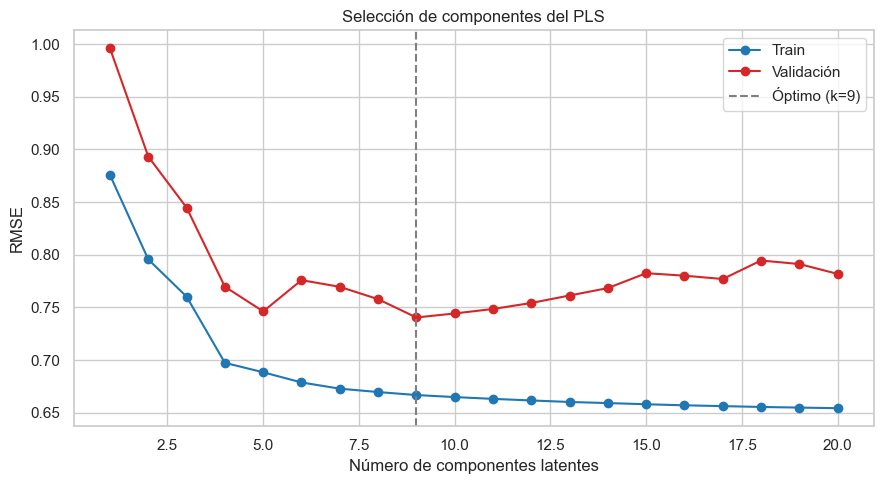

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(barrido["componentes"], barrido["RMSE_train"], marker="o",
        label="Train", color="#1f77b4")
ax.plot(barrido["componentes"], barrido["RMSE_val"], marker="o",
        label="Validación", color="#d62728")
ax.axvline(mejor_k, color="gray", linestyle="--", label=f"Óptimo (k={mejor_k})")
ax.set_xlabel("Número de componentes latentes")
ax.set_ylabel("RMSE")
ax.set_title("Selección de componentes del PLS")
ax.legend()
plt.tight_layout()
plt.show()

La curva de train baja siempre —más componentes, más flexibilidad—. La de validación
tiene un mínimo, y a partir de ahí el PLS empieza a ajustar ruido. Es la misma forma que
la curva de early stopping de XGBoost, pero sobre un solo parámetro interpretable.

## 5. Diagnóstico PLS: T² de Hotelling y Q residual

Las dos piezas que justifican tener PLS en el proyecto.

- **T²** mide la distancia de una muestra al centro del modelo, *dentro* del espacio
  latente. Alto = operación extrema pero reconocible.
- **Q (SPE)** mide lo que queda fuera del espacio latente: la parte de la muestra que el
  modelo no sabe representar. Alto = estructura desconocida.

La distinción importa. T² alto con Q bajo es "estamos operando al límite, pero el modelo
entiende esta situación". Q alto es "esto no se parece a nada de lo que aprendí", y ahí
la predicción no es fiable aunque salga un número razonable.

In [ ]:
def diagnostico_pls(pipeline, X, X_train_ref=None):
    """Calcula T² de Hotelling y Q residual (SPE) para cada muestra."""
    scaler = pipeline.named_steps["scaler"]
    pls = pipeline.named_steps["pls"]

    Xs = scaler.transform(X)
    T = pls.transform(Xs)                    # scores en el espacio latente

    # T²: distancia de Mahalanobis en el espacio de scores
    var_scores = pls.x_scores_.var(axis=0, ddof=1)
    T2 = np.sum((T ** 2) / var_scores, axis=1)

    # Q: energía del residuo tras reconstruir desde los scores
    X_rec = T @ pls.x_loadings_.T
    Q = np.sum((Xs - X_rec) ** 2, axis=1)

    return T2, Q


def limites_control(T2_train, Q_train, n_comp, alfa=0.99):
    """Límites de control para T² y Q, estimados sobre el train."""
    n = len(T2_train)
    # T²: distribución F escalada
    lim_T2 = (n_comp * (n - 1) / (n - n_comp)) * f_dist.ppf(alfa, n_comp,
                                                            n - n_comp)
    # Q: aproximación empírica por percentil (robusta y suficiente aquí)
    lim_Q = np.percentile(Q_train, alfa * 100)
    return lim_T2, lim_Q


pls_demo = Pipeline([
    ("scaler", StandardScaler()),
    ("pls", PLSRegression(n_components=mejor_k, scale=False)),
]).fit(tr[FEATURES], tr[col])

T2_tr, Q_tr = diagnostico_pls(pls_demo, tr[FEATURES])
T2_te, Q_te = diagnostico_pls(pls_demo, te[FEATURES])
lim_T2, lim_Q = limites_control(T2_tr, Q_tr, mejor_k)

print(f"Límite T² (99%): {lim_T2:.1f}")
print(f"Límite Q  (99%): {lim_Q:.1f}\n")
print(f"Muestras de TEST fuera de control:")
print(f"  T² excedido: {(T2_te > lim_T2).mean():.1%}")
print(f"  Q  excedido: {(Q_te > lim_Q).mean():.1%}")
print(f"  Alguno de los dos: {((T2_te > lim_T2) | (Q_te > lim_Q)).mean():.1%}")

Límite T² (99%): 22.0
Límite Q  (99%): 517.6

Muestras de TEST fuera de control:
  T² excedido: 19.5%
  Q  excedido: 50.4%
  Alguno de los dos: 53.9%


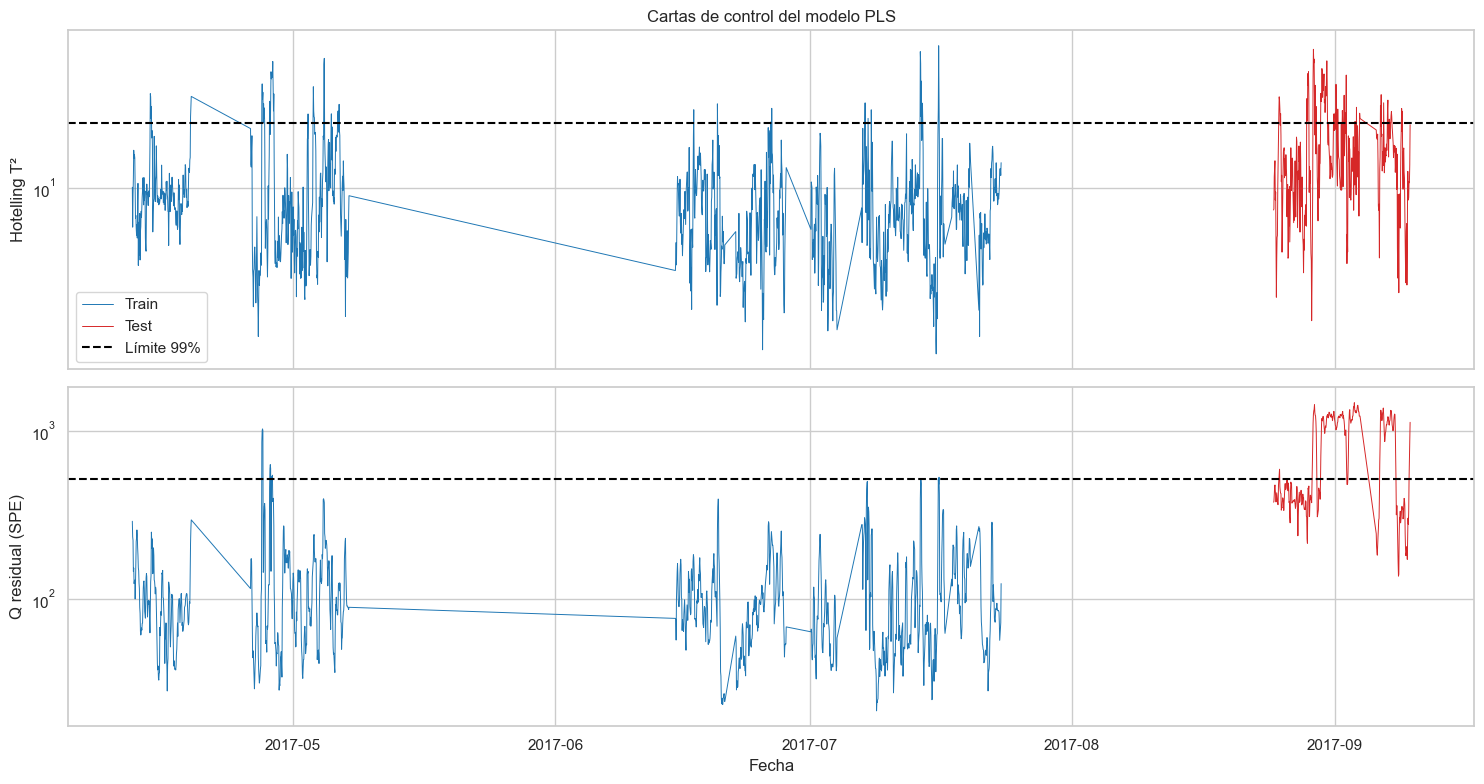

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(tr[TIMESTAMP_COL], T2_tr, linewidth=0.7, color="#1f77b4",
             label="Train")
axes[0].plot(te[TIMESTAMP_COL], T2_te, linewidth=0.7, color="#d62728",
             label="Test")
axes[0].axhline(lim_T2, color="black", linestyle="--", label="Límite 99%")
axes[0].set_ylabel("Hotelling T²")
axes[0].set_yscale("log")
axes[0].set_title("Cartas de control del modelo PLS")
axes[0].legend()

axes[1].plot(tr[TIMESTAMP_COL], Q_tr, linewidth=0.7, color="#1f77b4")
axes[1].plot(te[TIMESTAMP_COL], Q_te, linewidth=0.7, color="#d62728")
axes[1].axhline(lim_Q, color="black", linestyle="--")
axes[1].set_ylabel("Q residual (SPE)")
axes[1].set_yscale("log")
axes[1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

**Esto es lo que XGBoost no te puede dar.** Si la línea roja se dispara por encima del
límite en el tramo final, el modelo te está avisando de que ha salido de su zona de
validez — sin necesidad de esperar al valor de laboratorio para descubrirlo por el error.

En la almazara, esta carta corriendo en tiempo real es la señal de "los experimentos han
empezado, no te fíes de la predicción". Y no requiere que etiquetes nada: sale del propio
modelo.

## 6. Entrenamiento de los dos modelos en todos los horizontes

Baseline de persistencia incluido: predecir que dentro de *h* horas el valor será el
mismo que ahora. Es el rival real.

In [ ]:
def evaluar(y_true, y_pred, modelo, h):
    return {
        "horizonte_h": h,
        "modelo": modelo,
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


resultados = []
detalle = {}
componentes_elegidos = {}

for h in HORIZONTES:
    tr_h, va_h, te_h, col_h = split(dataset, h)

    # --- Persistencia -----------------------------------------------------
    resultados.append(evaluar(te_h[col_h], te_h[TARGET], "Persistencia", h))

    # --- PLS --------------------------------------------------------------
    barr = barrer_componentes(tr_h, va_h, col_h)
    k = int(barr.loc[barr["RMSE_val"].idxmin(), "componentes"])
    componentes_elegidos[h] = k

    pls = Pipeline([
        ("scaler", StandardScaler()),
        ("pls", PLSRegression(n_components=k, scale=False)),
    ]).fit(tr_h[FEATURES], tr_h[col_h])
    pred_pls = pls.predict(te_h[FEATURES]).ravel()
    resultados.append(evaluar(te_h[col_h], pred_pls, "PLS", h))

    # --- XGBoost ----------------------------------------------------------
    xgbm = xgb.XGBRegressor(
        n_estimators=2000, learning_rate=0.03, max_depth=4,
        subsample=0.8, colsample_bytree=0.6, min_child_weight=10,
        reg_lambda=5.0,
        early_stopping_rounds=50, eval_metric="rmse",
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    xgbm.fit(tr_h[FEATURES], tr_h[col_h],
             eval_set=[(va_h[FEATURES], va_h[col_h])], verbose=False)
    pred_xgb = xgbm.predict(te_h[FEATURES])
    resultados.append(evaluar(te_h[col_h], pred_xgb, "XGBoost", h))

    detalle[h] = {"te": te_h, "col": col_h, "pls": pred_pls,
                  "xgb": pred_xgb, "modelo_pls": pls, "modelo_xgb": xgbm}

    print(f"h={h:>2}h | PLS k={k:>2} | XGB árboles={xgbm.best_iteration:>4} | "
          f"RMSE persist={resultados[-3]['RMSE']:.4f} "
          f"PLS={resultados[-2]['RMSE']:.4f} XGB={resultados[-1]['RMSE']:.4f}")

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:target_ruidoso_lag1: object, target_ruidoso_lag2: object, target_ruidoso_lag3: object

Nota sobre los hiperparámetros de XGBoost: `max_depth=4`, `min_child_weight=10` y
`reg_lambda=5` son deliberadamente conservadores. Con pocos miles de filas, la
configuración por defecto (profundidad 6, sin regularización explícita) memoriza. Si
XGBoost pierde aquí, que no sea por no haberlo intentado con una configuración adecuada
al tamaño del dataset.

## 7. Resultados

In [ ]:
tabla = (pd.DataFrame(resultados)
         .pivot(index="horizonte_h", columns="modelo",
                values=["RMSE", "MAE", "R2"]))

mejora = pd.DataFrame({
    "PLS_vs_persist_%": (tabla[("RMSE", "Persistencia")] - tabla[("RMSE", "PLS")])
                        / tabla[("RMSE", "Persistencia")] * 100,
    "XGB_vs_persist_%": (tabla[("RMSE", "Persistencia")] - tabla[("RMSE", "XGBoost")])
                        / tabla[("RMSE", "Persistencia")] * 100,
})

print("MÉTRICAS")
print(tabla.round(4).to_string())
print("\nMEJORA SOBRE PERSISTENCIA (positivo = mejor que no hacer nada)")
print(mejora.round(2).to_string())

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

piv = pd.DataFrame(resultados).pivot(index="horizonte_h", columns="modelo",
                                     values="RMSE")
piv.plot(marker="o", ax=axes[0])
axes[0].set_title("RMSE por horizonte")
axes[0].set_xlabel("Horizonte (h)")

piv_r2 = pd.DataFrame(resultados).pivot(index="horizonte_h", columns="modelo",
                                        values="R2")
piv_r2.plot(marker="o", ax=axes[1])
axes[1].axhline(0, color="gray", linestyle=":")
axes[1].set_title("R² por horizonte")
axes[1].set_xlabel("Horizonte (h)")

mejora.plot(marker="o", ax=axes[2])
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_title("Mejora sobre persistencia (%)")
axes[2].set_xlabel("Horizonte (h)")
axes[2].set_ylabel("%")

plt.tight_layout()
plt.show()

**El panel derecho es el veredicto.** Por debajo de la línea roja, el modelo pierde
contra no hacer nada. Que un R² sea positivo no significa nada si la persistencia da uno
mejor.

Presta atención a la forma de las curvas, no solo a los valores. La persistencia se
degrada al crecer el horizonte —es inevitable, el proceso se aleja de su estado actual—.
Si los modelos se degradan *más rápido* que ella, están aprendiendo inercia y no
dinámica.

## 8. Inspección visual

In [ ]:
fig, axes = plt.subplots(len(HORIZONTES), 1, figsize=(15, 3.4 * len(HORIZONTES)))

for ax, h in zip(np.atleast_1d(axes), HORIZONTES):
    d = detalle[h]
    t = d["te"][TIMESTAMP_COL]

    ax.plot(t, d["te"][d["col"]], label="Real", color="#1f77b4", linewidth=1.3)
    ax.plot(t, d["pls"], label="PLS", color="#2ca02c", alpha=0.85, linewidth=1.1)
    ax.plot(t, d["xgb"], label="XGBoost", color="#ff7f0e", alpha=0.85, linewidth=1.1)
    ax.plot(t, d["te"][TARGET], label="Persistencia", color="gray",
            linestyle="--", alpha=0.6, linewidth=0.9)

    ax.set_title(f"Horizonte {h} h")
    ax.set_ylabel(TARGET, fontsize=9)
    ax.legend(fontsize=8, ncol=4)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

**Qué buscar aquí, más allá del error.** Si una curva de predicción va sistemáticamente
retrasada respecto a la azul, ese modelo copia el pasado en vez de anticipar. Se ve a
simple vista y no aparece en ninguna métrica agregada.

Fíjate también en el comportamiento en los picos. Un modelo que aplana los extremos y se
queda en la media tiene buen RMSE y valor operativo nulo: precisamente los picos de
sílice son los que exigirían actuar.

In [ ]:
h_foco = 6      # cambia para inspeccionar otro horizonte
d = detalle[h_foco]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

for pred, nombre, color in [(d["pls"], "PLS", "#2ca02c"),
                            (d["xgb"], "XGBoost", "#ff7f0e")]:
    axes[0].scatter(d["te"][d["col"]], pred, alpha=0.35, s=14,
                    label=nombre, color=color)
lims = [d["te"][d["col"]].min(), d["te"][d["col"]].max()]
axes[0].plot(lims, lims, "r--", linewidth=2)
axes[0].set_xlabel("Real")
axes[0].set_ylabel("Predicho")
axes[0].set_title(f"Real vs predicho — {h_foco} h")
axes[0].legend()

for pred, nombre, color in [(d["pls"], "PLS", "#2ca02c"),
                            (d["xgb"], "XGBoost", "#ff7f0e")]:
    sns.histplot(d["te"][d["col"]].to_numpy() - pred, bins=40, stat="density",
                 element="step", fill=False, color=color, label=nombre, ax=axes[1])
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_title("Distribución de residuos")
axes[1].legend()

# Coeficientes PLS: qué variables pesan en el modelo lineal
coefs = pd.Series(
    d["modelo_pls"].named_steps["pls"].coef_.ravel(), index=FEATURES
).sort_values(key=abs, ascending=False).head(15)
axes[2].barh(coefs.index[::-1], coefs.values[::-1], color="#2ca02c")
axes[2].set_title(f"Top coeficientes PLS — {h_foco} h")
axes[2].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()

Los coeficientes del PLS son directamente legibles: signo y magnitud dicen cómo afecta
cada variable. Compáralos con las importancias de XGBoost de la celda siguiente — si
ambos modelos apuntan a las mismas variables, tienes confianza en que la señal es real y
no un artefacto de un algoritmo concreto.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
xgb.plot_importance(d["modelo_xgb"], importance_type="gain", max_num_features=15,
                    ax=ax, color="#ff7f0e")
ax.set_title(f"Top features XGBoost (gain) — {h_foco} h")
plt.tight_layout()
plt.show()

Si el ranking está dominado por `% Silica Concentrate` y sus lags, el modelo es
autorregresivo: usa su propia historia, no el proceso. Eso da RMSE decente y cero valor
accionable — no puedes intervenir sobre una predicción que solo mira al target.

Lo que buscas arriba son variables **manipulables**: `Amina Flow`, `Starch Flow`, niveles
de columna. Esas permiten actuar.

## 9. Rendimiento dentro y fuera de control

Cruce de las dos mitades del notebook: ¿predicen peor los modelos justo en las muestras
que el diagnóstico PLS marcó como fuera de rango?

Si la respuesta es sí, el detector funciona y tienes una señal accionable: cuando T² o Q
se disparan, descarta la predicción en lugar de actuar sobre ella.

In [ ]:
d = detalle[h_foco]
tr_h, va_h, te_h, col_h = split(dataset, h_foco)

T2_tr_h, Q_tr_h = diagnostico_pls(d["modelo_pls"], tr_h[FEATURES])
T2_te_h, Q_te_h = diagnostico_pls(d["modelo_pls"], te_h[FEATURES])
lim_T2_h, lim_Q_h = limites_control(T2_tr_h, Q_tr_h,
                                    componentes_elegidos[h_foco])

fuera = (T2_te_h > lim_T2_h) | (Q_te_h > lim_Q_h)

print(f"Horizonte {h_foco} h — muestras de test fuera de control: "
      f"{fuera.sum()} de {len(fuera)} ({fuera.mean():.1%})\n")

filas = []
for nombre, pred in [("PLS", d["pls"]), ("XGBoost", d["xgb"]),
                     ("Persistencia", te_h[TARGET].to_numpy())]:
    y = te_h[col_h].to_numpy()
    fila = {"modelo": nombre}
    if (~fuera).sum() > 5:
        fila["RMSE_en_control"] = root_mean_squared_error(y[~fuera], pred[~fuera])
    if fuera.sum() > 5:
        fila["RMSE_fuera_control"] = root_mean_squared_error(y[fuera], pred[fuera])
    filas.append(fila)

pd.DataFrame(filas).round(4)

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))

err_pls = np.abs(te_h[col_h].to_numpy() - d["pls"])
ax.scatter(Q_te_h[~fuera], err_pls[~fuera], alpha=0.4, s=14,
           color="steelblue", label="En control")
ax.scatter(Q_te_h[fuera], err_pls[fuera], alpha=0.6, s=18,
           color="crimson", label="Fuera de control")
ax.axvline(lim_Q_h, color="black", linestyle="--", label="Límite Q")
ax.set_xscale("log")
ax.set_xlabel("Q residual (escala log)")
ax.set_ylabel("Error absoluto del PLS")
ax.set_title("¿Anticipa el diagnóstico Q el error de predicción?")
ax.legend()
plt.tight_layout()
plt.show()

Una nube ascendente confirma que Q predice el error **antes** de conocerlo. Ese es el
mecanismo que quieres en producción: no un modelo que nunca falla, sino uno que sabe
cuándo va a fallar.

Si la nube es plana, el diagnóstico no discrimina aquí y habría que revisar el cálculo de
límites o el número de componentes.

## 10. Conclusiones

Rellena con los números que salgan:

- [ ] ¿Bate alguno de los dos a la persistencia? ¿En qué horizontes?
- [ ] ¿Gana PLS o XGBoost? ¿Por cuánto?
- [ ] ¿Cuántas componentes usa el PLS? (pocas = el proceso tiene estructura simple)
- [ ] ¿Coinciden las variables importantes de ambos modelos?
- [ ] ¿Aparecen variables manipulables, o todo es autorregresivo?
- [ ] ¿Sube el error en las muestras fuera de control? ¿Cuánto?

### Cómo interpretar cada desenlace

**Si PLS gana o empata** — con esta ratio muestras/feature es el resultado esperable, y
además te llevas los diagnósticos gratis. Para la almazara, ese sería el sistema a
montar.

**Si XGBoost gana claramente** — hay no-linealidad real que el lineal no captura.
Merece la pena, pero necesitarás un detector de extrapolación aparte: puedes mantener un
PLS en paralelo solo para T²/Q, aunque no lo uses para predecir.

**Si ninguno bate a la persistencia en ningún horizonte** — es un resultado, no un
fracaso. Significa que con las variables disponibles y el target horario, la sílice no es
predecible más allá de su propia inercia. Documentarlo con esta metodología vale más que
un R² alto obtenido con un split barajado.

### Siguiente paso
Con el modelo elegido, la ventana móvil: reentrenar periódicamente descartando datos
antiguos, barriendo el tamaño de ventana. Ahora que las muestras son horas y no filas de
20 s, los tamaños de ventana de la literatura (decenas de muestras etiquetadas) son
directamente aplicables.